In [2]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
PREDSDIR  = CONFIGS['filepaths']['predictions']
LATRANGE  = CONFIGS['domain']['latrange']
LONRANGE  = CONFIGS['domain']['lonrange']
SPLIT     = 'test'
_MODELS   = CONFIGS['experiments']
MODELS    = {}
for _name,_rc in _MODELS['pod']['runs'].items():
    MODELS[_name] = _rc.get('description',_name)
for _name,_rc in _MODELS['nn']['runs'].items():
    MODELS[_name] = _rc.get('description',_name)
for _name,_eqspec in _MODELS['sr'].get('optimizedeqs',{}).items():
    MODELS[_name] = _eqspec.get('description',_name)

In [4]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()

results = {}
for name in MODELS.keys():
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(filepath):
        continue
    with xr.open_dataset(filepath) as ds:
        pred = ds.tp.load()
    if 'seed' in pred.dims:
        pred = pred.mean('seed')
    if 'complexity' in pred.dims:
        pred = pred.isel(complexity=0)
    ytrue,ypred   = xr.align(truetp,pred,join='inner')
    results[name] = (ytrue.squeeze(),ypred.squeeze())

print(f'Loaded {len(results)}/{len(MODELS)} models!')

# Land mask from land-fraction file: lf >= 0.5 → land, < 0.5 → ocean
_lf_path = os.path.join(CONFIGS['filepaths']['interim'], 'lf.nc')
with xr.open_dataset(_lf_path) as _ds:
    _lfvar = list(_ds.data_vars)[0]
    _lf    = _ds[_lfvar].squeeze().load()
_ref      = next(iter(results.values()))[0].isel(time=0)
_lf_grid  = _lf.interp(lat=_ref.lat, lon=_ref.lon, method='nearest')
LAND_MASK = (_lf_grid.values >= 0.5)
print(f'Land mask: {LAND_MASK.sum()} land, {(~LAND_MASK).sum()} ocean pixels')

Loaded 9/9 models!
Land mask: 194 land, 457 ocean pixels


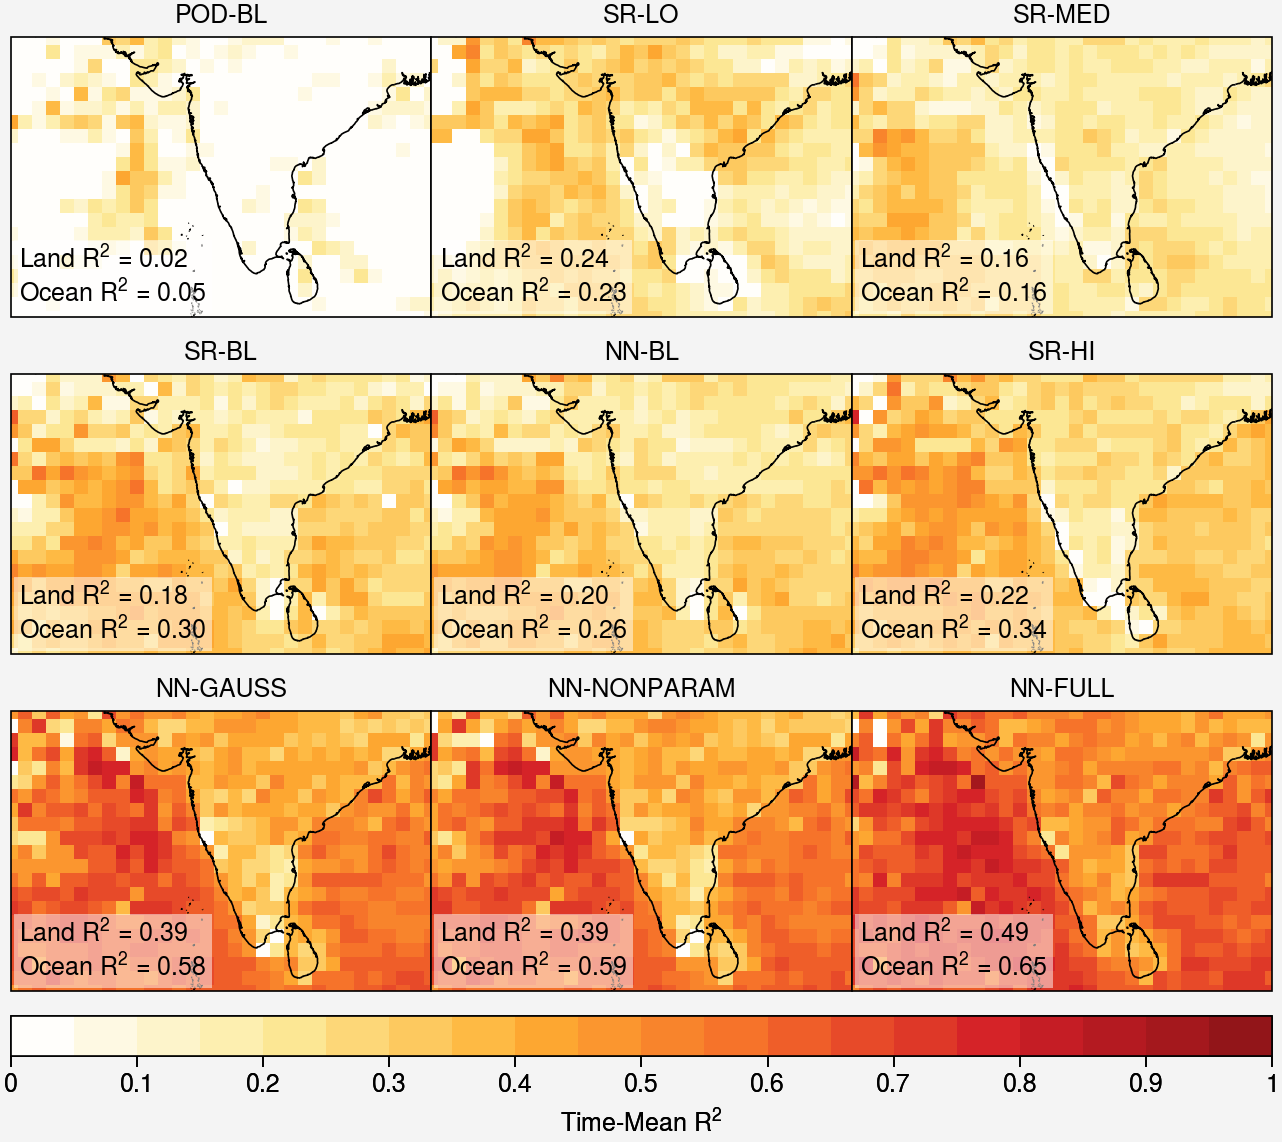

In [5]:
def spatial_r2(ytrue,ypred):
    ssres = ((ytrue-ypred)**2).sum('time',skipna=True)
    sstot = ((ytrue-ytrue.mean('time',skipna=True))**2).sum('time',skipna=True)
    return (1-ssres/sstot).squeeze()

def scalar_r2(ytrue, ypred, land_mask):
    # Pooled R² per region: 1 - sum(SSres) / sum(SStot) across all pixels in region.
    # Matches pareto.ipynb get_r2; avoids the negative-mean artifact from averaging per-pixel R²
    # (pixels with near-zero variance get wildly negative per-pixel R², dragging down a simple mean).
    ssres = ((ytrue-ypred)**2).sum('time',skipna=True).values.ravel()
    sstot = ((ytrue-ytrue.mean('time',skipna=True))**2).sum('time',skipna=True).values.ravel()
    fin   = np.isfinite(ssres) & np.isfinite(sstot)
    land  = land_mask.ravel()
    r2_land  = float(1 - ssres[land  & fin].sum() / sstot[land  & fin].sum())
    r2_ocean = float(1 - ssres[~land & fin].sum() / sstot[~land & fin].sum())
    return r2_land, r2_ocean

def scalar_mse(ytrue, ypred, land_mask):
    mse  = ((ytrue-ypred)**2).mean('time',skipna=True).values.ravel()
    fin  = np.isfinite(mse)
    land = land_mask.ravel()
    return float(mse[land  & fin].mean()), float(mse[~land & fin].mean())

names = sorted([n for n in MODELS.keys() if n in results],
               key=lambda n: float(spatial_r2(*results[n]).mean()))
if 'pod_bl' in names and 'sr_lo' in names:
    i_pod,i_sr = names.index('pod_bl'),names.index('sr_lo')
    if i_sr < i_pod:
        names.remove('sr_lo')
        names.insert(names.index('pod_bl') + 1, 'sr_lo')
n     = len(names)
ncols = 3
nrows = int(np.ceil(n/ncols))

fig,axs = pplt.subplots(nrows=nrows,ncols=ncols,proj='cyl',figwidth=6.5,share=False,wspace=0)
axs.format(coast=True,borders=False,latlim=LATRANGE,lonlim=LONRANGE,latlines=5,lonlines=5,grid=False)
m = None
for ax,name in zip(axs,names):
    ytrue,ypred  = results[name]
    r2           = spatial_r2(ytrue,ypred)
    r2l,r2o      = scalar_r2(ytrue,ypred,LAND_MASK)
    m = ax.pcolormesh(r2.lon,r2.lat,r2,cmap='ColdHot',cmap_kw={'left':0.5},vmin=0,vmax=1,levels=21)
    ax.format(title=MODELS.get(name,name))
    ax.text(0.02,0.03,f'Land R$^2$ = {r2l:.2f} \nOcean R$^2$ = {r2o:.2f}',
            transform=ax.transAxes,ha='left',va='bottom',
            bbox=dict(facecolor='white',alpha=0.5,edgecolor='none',pad=2))
for ax in axs[n:]:
    ax.set_visible(False)
fig.colorbar(m,loc='b',label='Time-Mean R$^2$',ticks=0.1)
pplt.show()
fig.save('../figs/fig_3.jpg')

In [6]:
# def spatial_mse(ytrue,ypred):
#     return ((ytrue-ypred)**2).mean('time',skipna=True).squeeze()

# # Common vmax: 95th percentile across all models (in mm²)
# _all_mse = np.concatenate([spatial_mse(*results[n]).values.ravel() for n in names])
# vmax_mse = float(np.nanpercentile(_all_mse,95))

# fig,axs = pplt.subplots(nrows=nrows,ncols=ncols,proj='cyl',figwidth=6.5,share=False,wspace=0)
# axs.format(coast=True,borders=False,latlim=LATRANGE,lonlim=LONRANGE,latlines=5,lonlines=5,grid=False)
# m = None
# for ax,name in zip(axs,names):
#     ytrue,ypred = results[name]
#     mse         = spatial_mse(ytrue,ypred)
#     msel,mseo   = scalar_mse(ytrue,ypred,LAND_MASK)
#     m = ax.pcolormesh(mse.lon,mse.lat,mse,cmap='ColdHot',cmap_kw={'left':0.5},
#                       vmin=0,vmax=vmax_mse,levels=21,extend='max')
#     ax.format(title=MODELS.get(name,name))
#     ax.text(0.03,0.03,f'Land = {msel:.2f} mm$^2$ \nOcean = {mseo:.2f} mm$^2$',
#             transform=ax.transAxes,ha='left',va='bottom',
#             bbox=dict(facecolor='white',alpha=0.5,edgecolor='none',pad=1.5))
# for ax in axs[n:]:
#     ax.set_visible(False)
# fig.colorbar(m,loc='b',label='Time-Mean MSE (mm$^2$)')
# pplt.show()
# fig.save('../figs/fig_3_mse.jpg')